# Les Algorithmes de Classification de Regression

Dans ce Jupyter NoteBook nous allons vous présenter 3 algorithmes : 
1. [Moindre Carré](#lsquare)
2. [Regression Quantile](#rian)
3. [Regression Polynomiale](#noe)

---

<a id="lsquare"></a>

# 1. Méthode des moindres carrés
#### Author : Omer GUNES


Dans cet exemple je vais essayer de manipuler ScikitLearn dans l'optique de prendre en main la regression en vous expliquant la methode des moindres carrés.

---

### 1ère Exemple avec des données **generer aléatoirement**

#### Etape 1 : Importer les dépendances nécessaires

In [64]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.linear_model import LinearRegression # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore

Generation d'un jeu de données simple, qui sera aléatoire. On va avoir X qui sera une serie de valeurs et on va l'appliquer un peu de bruit.

In [62]:
np.random.seed(np.random.randint(100))
x = 1000 * np.random.rand(100, 1)  # Génération des valeurs x
y = np.random.randint(2) + np.random.randint(1) * x + np.random.randn(100, 1)  # Génération des valeurs y avec un peu de bruit

On va maintenant séparer les données en deux groupes. Premierement on va avoir les données d'entrainement, deuxiemement on va avoir les données de test.

In [65]:
# Séparer les données en ensembles d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=np.random.randint(100))

On va maintenant créer notre modèle de regression linéaire grâce à la methode de LinearRegression() fourni par sklearn.

In [66]:
# Créer un modèle de régression linéaire
model = LinearRegression()

On va maintenant entrainer notre modèle avec les données qu'on avait marqué comme données d'entrainement.

In [ ]:
# Entraîner le modèle sur l'ensemble d'entraînement
model.fit(x_train, y_train)

Après qu'on a entrainer notre algorithme on va maintenant le tester avec les données qu'on avait etiquetté comme données de test. 

In [ ]:
# Prédire les valeurs y pour les données de test
y_pred = model.predict(x_test)

Maintenant on va evaluer notre modele pour cela on va calculer deux valeurs.

<a id="expliquation"></a>

La première va etre le MSE (Mean Squared Error) elle va nous permettre de mesurer l'écart moyen au carré entre les valeurs qui sont réelle et les valeurs qui auront été prédites par notre modèle. Plus le MSE sera petit, plus le modèle est performant car nos valeurs predites seront très proches des valeurs rééles.

La seconde va etre R2 (Coefficient de determination) elle va nous indiquer la variance de notre modèle (compris entre [0, 1])
Plus R2 est proche de 1 plus notre modèle est "signifiant", le cas contraire une R2 prche de 0 veut dire que notre modèle "signifie rien".

Mean Squared Error (MSE): 0.9575224768035735
R-squared (R2): -0.23375395915475417


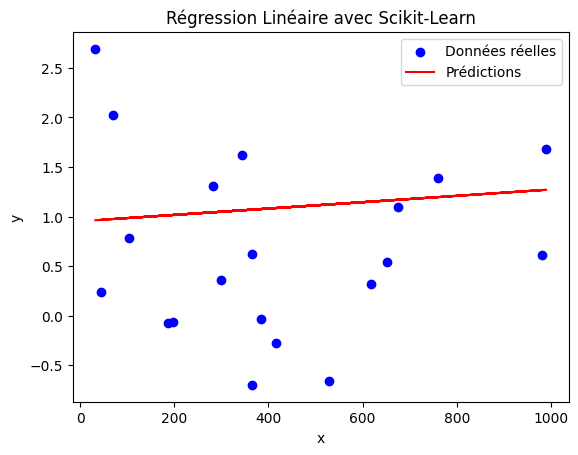

In [63]:


# Évaluer le modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# Afficher les résultats
plt.scatter(x_test, y_test, color="blue", label="Données réelles")
plt.plot(x_test, y_pred, color="red", label="Prédictions")
plt.title("Régression Linéaire avec Scikit-Learn")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# 2ème Exemple avec des données du diabète

### Etape 1 : Importer les dépendances



In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np # type: ignore

from sklearn import datasets, linear_model # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore

#### Etape 2 : Charger le dataset

In [67]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

#### Etape 3 :  Utiliser uniquement une valeurs et separées les valeurs d'entrainement et de test.

In [ ]:
diabetes_X = diabetes_X[:, np.newaxis, 2]

diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

#### Etape 4 : Creer le modele de regression lineaire

In [68]:
regr = linear_model.LinearRegression()

#### Etape 5 : Entrainement du modèle avec les données d'entrainement puis le modèle va effectuer des predictions avec les données de test.

In [69]:
regr.fit(diabetes_X_train, diabetes_y_train)

diabetes_y_pred = regr.predict(diabetes_X_test)

#### Etape 6 : On va afficher les coefficient de regression, le MSE ([expliqué ici](#expliquation)), et le coefficient de determination ([expliqué ici](#expliquation)).

In [3]:
print("Coefficients: \n", regr.coef_)
print("Mean squared error: %.2f" % mean_squared_error(diabetes_y_test, diabetes_y_pred))
print("Coefficient of determination: %.2f" % r2_score(diabetes_y_test, diabetes_y_pred))

Coefficients: 
 [938.23786125]
Mean squared error: 2548.07
Coefficient of determination: 0.47


### Etape 6 : Affichage du graphes pour un resultat visuel. 

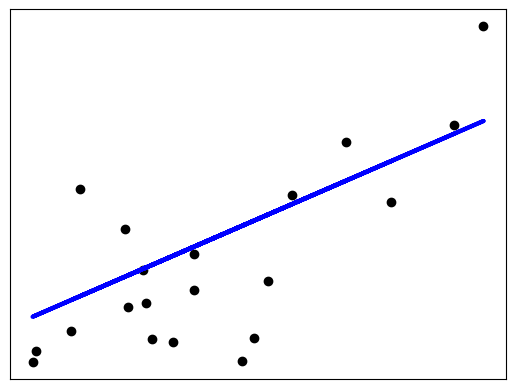

In [70]:
plt.scatter(diabetes_X_test, diabetes_y_test, color="black")
plt.plot(diabetes_X_test, diabetes_y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

---

<a id="rian"></a>

## 2. Regression Quantile (Quantile Regression)
### avec le débit de la Saugeen River
#### Author : Rayanne MELLAH

----

In [71]:
#!pip install --force-reinstall -v "numpy==1.24.0"
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import QuantileRegressor
from sklearn.model_selection import train_test_split

from sklearn.datasets import fetch_openml

In [72]:
sizeSample = 1_000
dataRaw =fetch_openml(data_id=46249,return_X_y=True)
data = dataRaw[0][:sizeSample]

In [73]:
data = pd.DataFrame(data)
print("n_sample=",data.shape[0])
print("n_feature=",len(data.columns))


data.sort_values("value_0")

n_sample= 1000
n_feature= 4


,id_series,date,value_0,time_step
625,0,1916-09-17,4.5,625
618,0,1916-09-10,5.3,618
615,0,1916-09-07,5.6,615
997,0,1917-09-24,5.8,997
620,0,1916-09-12,5.9,620
...,...,...,...,...
823,0,1917-04-03,216.0,823
818,0,1917-03-29,252.0,818
817,0,1917-03-28,323.0,817
816,0,1917-03-27,371.0,816


/home/omergs/sklearn-env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but QuantileRegressor was fitted with feature names
  warnings.warn(
/home/omergs/sklearn-env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but QuantileRegressor was fitted with feature names
  warnings.warn(
/home/omergs/sklearn-env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but QuantileRegressor was fitted with feature names
  warnings.warn(


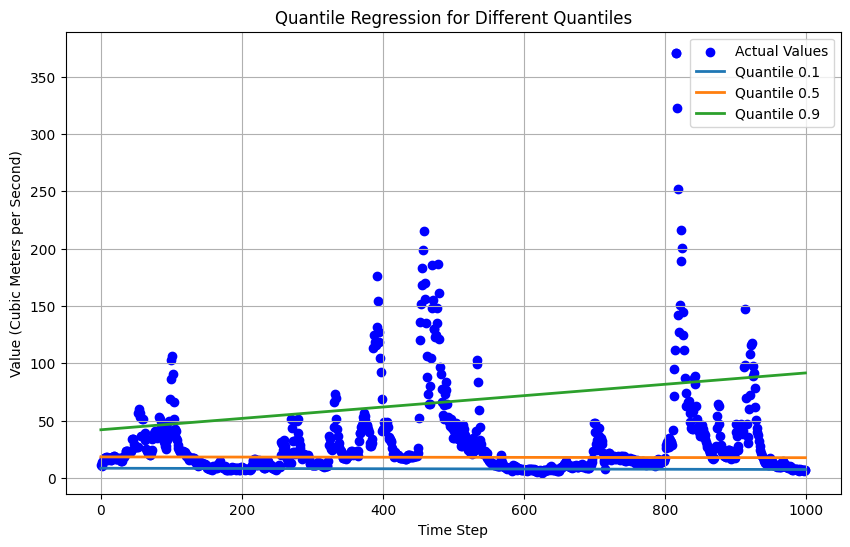

In [74]:
df = data


X = df[['time_step']]  # feature
y = df['value_0']      # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

quantiles = [0.1, 0.5, 0.9]  # Define quantiles (10th percentile, median, and 90th percentile)
models = {}
# fit the quantiles
for q in quantiles:
    model = QuantileRegressor(quantile=q, alpha=0).fit(X_train, y_train)
    models[q] = model


plt.figure(figsize=(10, 6))
time_steps = np.arange(X['time_step'].min(), X['time_step'].max() + 1).reshape(-1, 1)

# Plot values
plt.scatter(X, y, color='blue', label='Actual Values')

# Plot the quantiles
for q in quantiles:
    y_pred = models[q].predict(time_steps)
    plt.plot(time_steps, y_pred, label=f'Quantile {q}', linewidth=2)


plt.xlabel('Time Step')
plt.ylabel('Value (Cubic Meters per Second)')
plt.title('Quantile Regression for Different Quantiles')
plt.legend()
plt.grid(True)
plt.show()


## Résultat
On peut voir avec la **médiane** (5ème décile) et le **1er décile** que le débit de la rivière est plutôt constant.

Mais avec le **9ème décile** (qui compte les crues lui) on voit que le débit moyen de la rivière monte.

Donc le débit normal de la rivière ne change presque pas mais les inondations sont de plus en plus forte.

---

<a id="noe"></a>

## 3. Regression Polynomiale
#### Author : Noé PARCOLLET

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

# Regression Polynomial

In [ ]:
#Methode pour approximer un effet polynomial, a éxécuter avec les deux cellules suivantes pour des resultats differents
def poly(x):
    return x* np.sin(x)


start = np.random.randint(-1, 1)
end = np.random.randint(10, 20)
nbPoints = np.random.randint(50, 100)
randSize = np.random.randint(20, 50)
x_plot = np.linspace(start, end, nbPoints)

In [ ]:
x_train = np.linspace(start, end, nbPoints)
rng = np.random.RandomState(0)
x_train = np.sort(rng.choice(x_train, size=randSize, replace=False))
y_train = poly(x_train)

# create 2D-array versions of these arrays to feed to transformers
X_train = x_train[:, np.newaxis]
X_plot = x_plot[:, np.newaxis]

In [ ]:
lw = 2
fig, ax = plt.subplots()
ax.set_prop_cycle(
    color=["black", "teal", "yellowgreen", "gold", "darkorange", "tomato"]
)
ax.plot(x_plot, poly(x_plot), linewidth=lw, label="ground truth")

# plot training points
ax.scatter(x_train, y_train, label="training points")

# polynomial features
for degree in [3, 4, 5]:
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1e-3))
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    ax.plot(x_plot, y_plot, label=f"degree {degree}")

# B-spline with 4 + 3 - 1 = 6 basis functions
model = make_pipeline(SplineTransformer(n_knots=4, degree=3), Ridge(alpha=1e-3))
model.fit(X_train, y_train)

y_plot = model.predict(X_plot)
ax.plot(x_plot, y_plot, label="B-spline")
ax.legend(loc="lower center")
ax.set_ylim(-20, 10)
plt.show()

# Resusltat et explication
Quand on regarde au niveau des paramètre fournit on peut voir que ce qui importe le plus est le nombre de points totaux non pas la taille même si très important, les debut et la fin servent a délimiter.
On fait un appel de np.sin pour simuler une polynomial sur la base d'un sinus avec des parametres pour changer le resulat final